In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pyqtgraph as pg

In [4]:
prices = pd.concat([pd.read_csv(f"prices_round_4_day_{i}.csv", delimiter=';') for i in range(1,4)])


# adding day column to trades
trades = [pd.read_csv(f"trades_round_4_day_{i}.csv", delimiter=';') for i in range(1,4)]
for day in range(1,4):
    trades[day-1]["day"] = day
trades = pd.concat(trades)


# adding iteration column to both dataframes
prices["iteration"] = (prices["day"] - 1) * 10000 + prices["timestamp"]/100
prices["iteration"] = prices["iteration"].astype(int)
trades["iteration"] = (trades["day"] - 1) * 10000 + trades["timestamp"]/100
trades["iteration"] = trades["iteration"].astype(int)

In [5]:
products = prices["product"].unique()
participants = pd.concat([trades["buyer"], trades["seller"]]).unique()

In [17]:
products

<ArrowStringArray>
['VELVETFRUIT_EXTRACT',       'HYDROGEL_PACK',            'VEV_6000',
            'VEV_5000',            'VEV_6500',            'VEV_5300',
            'VEV_5400',            'VEV_4000',            'VEV_5100',
            'VEV_5200',            'VEV_5500',            'VEV_4500']
Length: 12, dtype: str

In [16]:
participants

<ArrowStringArray>
['Mark 01', 'Mark 38', 'Mark 55', 'Mark 67', 'Mark 14', 'Mark 22', 'Mark 49']
Length: 7, dtype: str

In [4]:
trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day,iteration
0,4500,Mark 01,Mark 22,VEV_5400,XIRECS,18.0,2,1,45
1,4500,Mark 01,Mark 22,VEV_5500,XIRECS,8.0,2,1,45
2,4500,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,2,1,45
3,4500,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,2,1,45
4,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1,51
...,...,...,...,...,...,...,...,...,...
1536,997100,Mark 01,Mark 22,VEV_5400,XIRECS,5.0,4,3,29971
1537,997100,Mark 01,Mark 22,VEV_5500,XIRECS,1.0,4,3,29971
1538,997100,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,4,3,29971
1539,997100,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,4,3,29971


Text(0.5, 0, 'Timestamp')

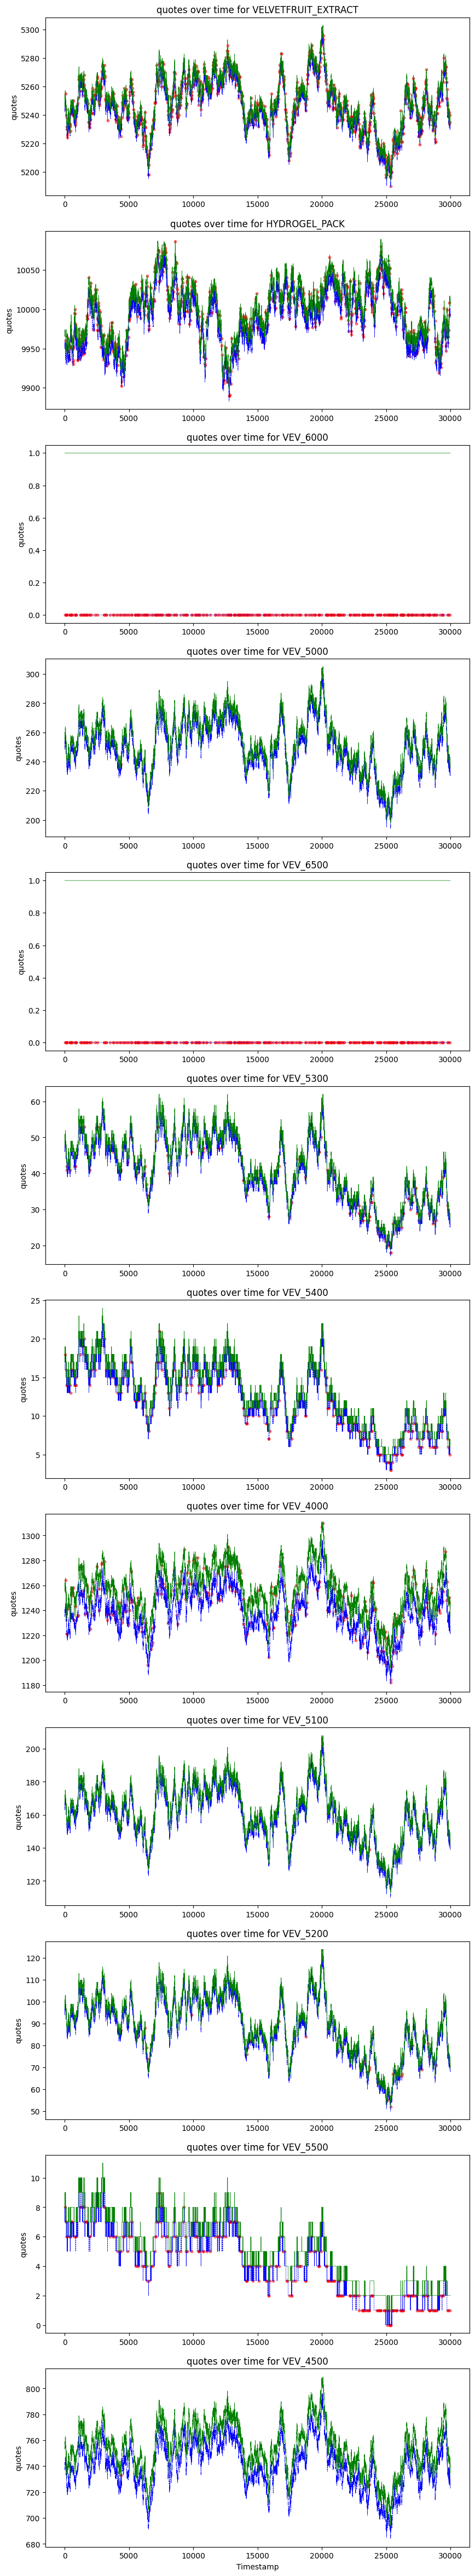

In [15]:
# plotting midprices over time for products in different axes

# make a dashboard so I can scroll through the trades of each market participant in participants

symbols = prices["product"].unique()

fig, axes = plt.subplots(len(symbols), 1, figsize=(10, 5*len(symbols)))
for i, symbol in enumerate(symbols):
    symbol_prices = prices[prices["product"] == symbol]
    axes[i].plot(symbol_prices["iteration"], symbol_prices["bid_price_1"], color = "blue", lw = 0.5, ls = "dashed")
    axes[i].plot(symbol_prices["iteration"], symbol_prices["ask_price_1"], color = "green", lw = 0.5)
    # plotting trades as scatter points
    symbol_trades = trades[trades["symbol"] == symbol]
    axes[i].scatter(symbol_trades["iteration"], symbol_trades["price"], color = "red", s = 10, alpha = 0.5)
    axes[i].set_title(f"quotes over time for {symbol}")
    axes[i].set_ylabel("quotes")
plt.xlabel("Timestamp")

In [6]:
trades

,timestamp,buyer,seller,symbol,currency,price,quantity,day,iteration
0,4500,Mark 01,Mark 22,VEV_5400,XIRECS,18.0,2,1,45
1,4500,Mark 01,Mark 22,VEV_5500,XIRECS,8.0,2,1,45
2,4500,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,2,1,45
3,4500,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,2,1,45
4,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1,51
...,...,...,...,...,...,...,...,...,...
1536,997100,Mark 01,Mark 22,VEV_5400,XIRECS,5.0,4,3,29971
1537,997100,Mark 01,Mark 22,VEV_5500,XIRECS,1.0,4,3,29971
1538,997100,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,4,3,29971
1539,997100,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,4,3,29971


In [7]:
# all bots in the market
pd.concat([trades["buyer"], trades["seller"]]).unique()

<ArrowStringArray>
['Mark 01', 'Mark 38', 'Mark 55', 'Mark 67', 'Mark 14', 'Mark 22', 'Mark 49']
Length: 7, dtype: str

In [8]:
# investigating buyers

# those who made the most trades as buyers (top 3), per symbol
trades.groupby("symbol")["buyer"].value_counts().groupby("symbol").head(3)


symbol               buyer  
HYDROGEL_PACK        Mark 38    515
                     Mark 14    496
                     Mark 22     11
VELVETFRUIT_EXTRACT  Mark 55    598
                     Mark 14    316
                     Mark 01    260
VEV_4000             Mark 14    232
                     Mark 38    209
                     Mark 22      1
VEV_4500             Mark 38      2
                     Mark 22      1
VEV_5000             Mark 38      2
                     Mark 22      1
VEV_5100             Mark 38      2
                     Mark 22      1
VEV_5200             Mark 14     33
                     Mark 01     11
                     Mark 38      2
VEV_5300             Mark 01    132
                     Mark 14     30
                     Mark 38      1
VEV_5400             Mark 01    263
                     Mark 14     13
VEV_5500             Mark 01    299
                     Mark 14      7
VEV_6000             Mark 01    317
VEV_6500             Mark 01    317

In [ ]:
trades

In [9]:
# Those who bought the most volume
trades.groupby("buyer")["quantity"].sum().sort_values(ascending=False)

buyer
Mark 01    6053
Mark 14    4510
Mark 55    3254
Mark 38    2493
Mark 67    1510
Mark 22     206
Mark 49     115
Name: quantity, dtype: int64

In [10]:
# investigating sellers
trades["seller"].value_counts()

seller
Mark 22    1542
Mark 14    1045
Mark 38     745
Mark 55     600
Mark 01     244
Mark 49     105
Name: count, dtype: int64

In [11]:
# those who sold the most volume
trades.groupby("seller")["quantity"].sum().sort_values(ascending=False)

seller
Mark 22    5683
Mark 14    4208
Mark 55    3297
Mark 38    2507
Mark 01    1375
Mark 49    1071
Name: quantity, dtype: int64

In [18]:
# adding order book data to each trade to investigate the state of the order book at the time of each trade
trades2 = trades.copy()
trades2.rename(columns={"symbol": "product"}, inplace=True)
trades_with_order_book = trades2.merge(prices, on=["iteration", "product"], how="left", suffixes=("", "_order_book"))   
trades_with_order_book.drop(columns=["day_order_book", "timestamp_order_book", "profit_and_loss", "currency", "timestamp"], inplace=True)


In [19]:

participant_trades = {}
for participant in participants:
    participant_trades[participant] = trades_with_order_book[(trades_with_order_book["buyer"] == participant) | (trades_with_order_book["seller"] == participant)]

In [20]:
participant_trades["Mark 38"]

,buyer,seller,product,price,quantity,day,iteration,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
4,Mark 38,Mark 22,HYDROGEL_PACK,9960.0,4,1,51,9952,11,9950.0,26.0,NaN,NaN,9960,4,9968.0,11.0,9971.0,26.0,9956.0
5,Mark 38,Mark 14,VEV_4000,1264.0,2,1,53,1243,14,1241.0,28.0,NaN,NaN,1264,14,1267.0,28.0,NaN,NaN,1253.5
7,Mark 38,Mark 14,HYDROGEL_PACK,9955.0,5,1,62,9939,12,9937.0,29.0,NaN,NaN,9955,12,9958.0,29.0,NaN,NaN,9947.0
24,Mark 38,Mark 14,HYDROGEL_PACK,9966.0,4,1,150,9951,13,9948.0,25.0,NaN,NaN,9966,13,9969.0,25.0,NaN,NaN,9958.5
25,Mark 14,Mark 38,VEV_4000,1221.0,2,1,167,1221,13,1219.0,15.0,NaN,NaN,1231,2,1242.0,13.0,1244.0,15.0,1226.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4268,Mark 38,Mark 14,HYDROGEL_PACK,9973.0,3,3,29862,9957,13,9954.0,25.0,NaN,NaN,9973,13,9975.0,25.0,NaN,NaN,9965.0
4270,Mark 38,Mark 14,HYDROGEL_PACK,9993.0,5,3,29898,9977,15,9975.0,21.0,NaN,NaN,9993,15,9996.0,21.0,NaN,NaN,9985.0
4271,Mark 38,Mark 14,HYDROGEL_PACK,10008.0,4,3,29924,9992,13,9989.0,29.0,NaN,NaN,10008,13,10010.0,29.0,NaN,NaN,10000.0
4272,Mark 38,Mark 14,VEV_4000,1246.0,3,3,29926,1225,8,1223.0,16.0,NaN,NaN,1246,8,1249.0,16.0,NaN,NaN,1235.5


,timestamp,buyer,seller,symbol,currency,price,quantity,day,iteration


Calculating profits of each participant for each product

In [ ]:
import pandas as pd
import numpy as np

def calculate_participant_pnl(trades, prices, participants):
    """
    Calculates realized PnL using Average Cost accounting, matching buys and sells,
    and liquidating any open positions at the mid-price at iteration 29999.
    """
    # 1. Get the final mid-prices for liquidation at iteration 29999
    final_prices = prices[prices['iteration'] == 29999].copy()
    final_prices['mid_price'] = (final_prices['bid_price_1'] + final_prices['ask_price_1']) / 2.0
    # Create a dictionary mapping product to its final mid price for quick lookup
    final_mid_dict = final_prices.set_index('product')['mid_price'].to_dict()

    # Determine if the volume column is named 'quantity' or 'volume'
    vol_col = 'quantity' if 'quantity' in trades.columns else 'volume'
    
    results = []
    products = trades['symbol'].unique()

    for participant in participants:
        for product in products:
            # 2. Isolate trades for this participant and product, sorted chronologically
            mask = ((trades['buyer'] == participant) | (trades['seller'] == participant)) & (trades['symbol'] == product)
            p_trades = trades[mask].copy().sort_values(by='iteration')
            
            if p_trades.empty:
                continue

            position = 0
            avg_cost = 0.0
            realized_pnl = 0.0
            
            # 3. Iterate through trades chronologically
            for _, trade in p_trades.iterrows():
                trade_price = trade['price']
                trade_qty = trade[vol_col]
                is_buyer = (trade['buyer'] == participant)
                
                if is_buyer:
                    if position >= 0: 
                        # Adding to a Long Position
                        new_position = position + trade_qty
                        avg_cost = ((position * avg_cost) + (trade_qty * trade_price)) / new_position
                        position = new_position
                    else: 
                        # Covering a Short Position
                        cover_qty = min(abs(position), trade_qty)
                        # Profit = Sold Price (avg_cost) - Bought Price (trade_price)
                        realized_pnl += cover_qty * (avg_cost - trade_price)
                        position += trade_qty
                        
                        if position > 0: # Flipped from net short to net long
                            avg_cost = trade_price
                        elif position == 0: # Flat
                            avg_cost = 0.0
                            
                else: # Participant is Seller
                    if position <= 0: 
                        # Adding to a Short Position
                        new_position = abs(position) + trade_qty
                        avg_cost = ((abs(position) * avg_cost) + (trade_qty * trade_price)) / new_position
                        position = -new_position
                    else: 
                        # Selling a Long Position
                        sell_qty = min(position, trade_qty)
                        # Profit = Sold Price (trade_price) - Bought Price (avg_cost)
                        realized_pnl += sell_qty * (trade_price - avg_cost)
                        position -= trade_qty
                        
                        if position < 0: # Flipped from net long to net short
                            avg_cost = trade_price
                        elif position == 0: # Flat
                            avg_cost = 0.0

            # 4. Liquidate remaining position at iteration 29999 mid_price
            if position != 0:
                final_mid = final_mid_dict.get(product, 0)
                if position > 0:
                    # Liquidate Long (Force Sell at mid_price)
                    realized_pnl += position * (final_mid - avg_cost)
                else:
                    # Liquidate Short (Force Buy at mid_price)
                    realized_pnl += abs(position) * (avg_cost - final_mid)
            
            results.append({
                'participant': participant,
                'product': product,
                'total_pnl': realized_pnl
            })

    return pd.DataFrame(results)

# Usage Example:
pnl_df = calculate_participant_pnl(trades, prices, participants)
pnl_df

,participant,product,total_pnl
0,Mark 01,VEV_5400,-5190.5
1,Mark 01,VEV_5500,-2495.0
2,Mark 01,VEV_6000,552.5
3,Mark 01,VEV_6500,552.5
4,Mark 01,VELVETFRUIT_EXTRACT,6899.0
5,Mark 01,VEV_5300,-4529.0
6,Mark 01,VEV_5200,155.0
7,Mark 38,HYDROGEL_PACK,-25110.0
8,Mark 38,VEV_4000,-7497.0
9,Mark 38,VEV_5300,-9.0


In [ ]:
trades[]

,timestamp,buyer,seller,symbol,currency,price,quantity,day,iteration
0,4500,Mark 01,Mark 22,VEV_5400,XIRECS,18.0,2,1,45
1,4500,Mark 01,Mark 22,VEV_5500,XIRECS,8.0,2,1,45
2,4500,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,2,1,45
3,4500,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,2,1,45
4,5100,Mark 38,Mark 22,HYDROGEL_PACK,XIRECS,9960.0,4,1,51
...,...,...,...,...,...,...,...,...,...
1536,997100,Mark 01,Mark 22,VEV_5400,XIRECS,5.0,4,3,29971
1537,997100,Mark 01,Mark 22,VEV_5500,XIRECS,1.0,4,3,29971
1538,997100,Mark 01,Mark 22,VEV_6000,XIRECS,0.0,4,3,29971
1539,997100,Mark 01,Mark 22,VEV_6500,XIRECS,0.0,4,3,29971
